# Previsão de Aprovação de Crédito
## Disciplina de Inteligência Artificial — Professor Munif — Unicesumar 2026

**Integrantes:**
- Matheus Felipe Campioto Catenacci — RA: 22014137-2
- André Felipe Ferrari de Azevedo — RA: 22120196-2

## 1. Instalação e Importação de Bibliotecas

In [65]:
# Instalação (necessário apenas no Colab)
!pip install scikit-learn pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score
)
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 2. Carregamento do Dataset

Dataset: **German Credit Data** (UCI Machine Learning Repository)
- 1000 registros de clientes
- 20 atributos (idade, renda, histórico de crédito, etc.)
- Variável alvo: **Risk** (bom pagador = 'good' / mau pagador = 'bad')

In [ ]:
# Carrega o dataset
# Se estiver no Colab, faça upload do arquivo german_credit_data.csv
# ou use o link direto abaixo

url = 'https://raw.githubusercontent.com/dsrscientist/dataset1/master/german_credit_data.csv'

try:
    df = pd.read_csv(url)
    print('Dataset carregado da internet!')
except:
    # Se não funcionar, faça upload manual no Colab
    from google.colab import files
    uploaded = files.upload()
    df = pd.read_csv('german_credit_data.csv')
    print('Dataset carregado do upload!')

print(f'Shape: {df.shape}')
df.head()

Saving german_credit_data.csv to german_credit_data (2).csv
Dataset carregado do upload!
Shape: (1000, 10)


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [ ]:
def criar_risk(row):
    pontos = 0
    if row['Saving accounts'] in ['little', None] or str(row['Saving accounts']) == 'nan':
        pontos += 2
    elif row['Saving accounts'] == 'moderate':
        pontos += 1
    if str(row['Checking account']) == 'nan':
        pontos += 2
    elif row['Checking account'] == 'little':
        pontos += 1
    if row['Credit amount'] > 5000:
        pontos += 1
    if row['Duration'] > 24:
        pontos += 1
    return 'bad' if pontos >= 4 else 'good'

df['Risk'] = df.apply(criar_risk, axis=1)
print('Coluna Risk criada!')
print(df['Risk'].value_counts())

Coluna Risk criada!
Risk
good    591
bad     409
Name: count, dtype: int64


## 3. Análise Exploratória dos Dados

In [ ]:
print('=== Informações do Dataset ===')
print(df.info())
print('\n=== Valores Nulos ===')
print(df.isnull().sum())
print('\n=== Estatísticas Descritivas ===')
df.describe()

=== Informações do Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB
None

=== Valores Nulos ===
Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount     

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


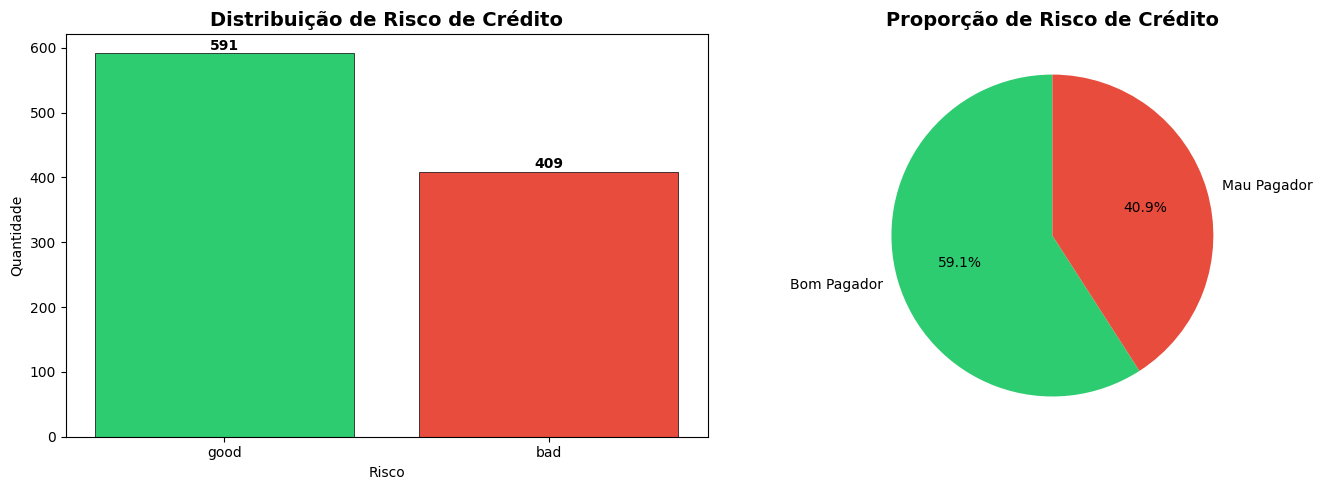

Gráfico salvo!


In [ ]:
# Distribuição da variável alvo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
risk_counts = df['Risk'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(risk_counts.index, risk_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Distribuição de Risco de Crédito', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Risco')
axes[0].set_ylabel('Quantidade')
for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pizza
axes[1].pie(risk_counts.values, labels=['Bom Pagador', 'Mau Pagador'],
            colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporção de Risco de Crédito', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('distribuicao_risco.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo!')

In [ ]:
def criar_risk(row):
    pontos = 0
    if row['Saving accounts'] in ['little', None] or str(row['Saving accounts']) == 'nan':
        pontos += 2
    elif row['Saving accounts'] == 'moderate':
        pontos += 1
    if str(row['Checking account']) == 'nan':
        pontos += 2
    elif row['Checking account'] == 'little':
        pontos += 1
    if row['Credit amount'] > 5000:
        pontos += 1
    if row['Duration'] > 24:
        pontos += 1
    return 'bad' if pontos >= 4 else 'good'

df['Risk'] = df.apply(criar_risk, axis=1)
print('Coluna Risk criada!')
print(df['Risk'].value_counts())

Coluna Risk criada!
Risk
good    591
bad     409
Name: count, dtype: int64


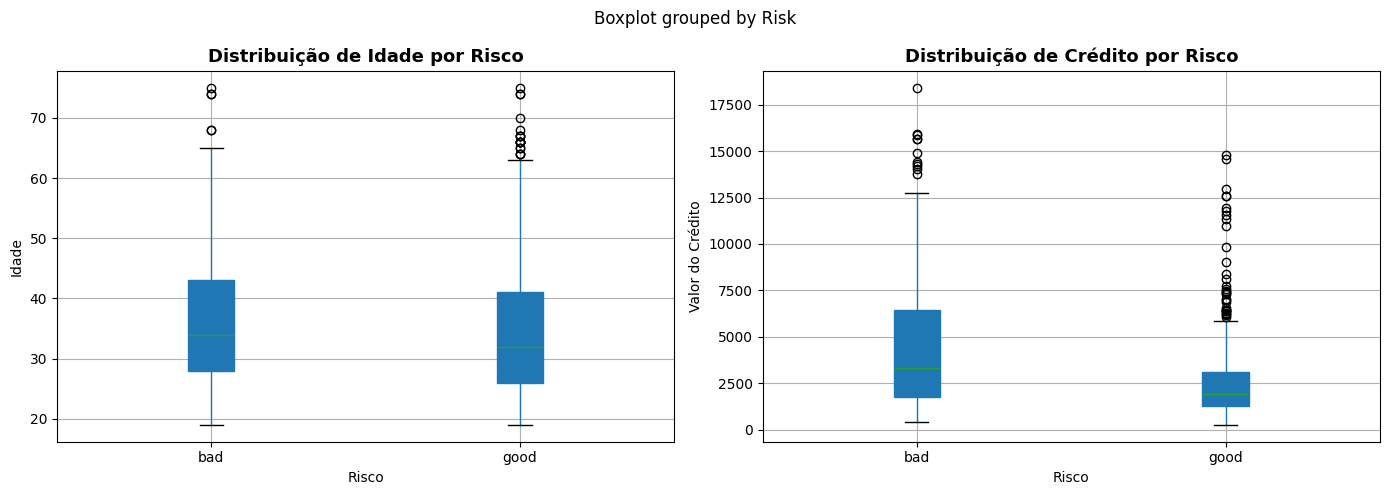

In [ ]:
# Análise de idade e crédito por risco
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Idade por risco
df.boxplot(column='Age', by='Risk', ax=axes[0], patch_artist=True)
axes[0].set_title('Distribuição de Idade por Risco', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Risco')
axes[0].set_ylabel('Idade')

# Crédito por risco
df.boxplot(column='Credit amount', by='Risk', ax=axes[1], patch_artist=True)
axes[1].set_title('Distribuição de Crédito por Risco', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Risco')
axes[1].set_ylabel('Valor do Crédito')

plt.tight_layout()
plt.savefig('analise_exploratoria.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Preparação dos Dados

In [ ]:
# Cópia do dataframe
df_model = df.copy()

# Remove coluna desnecessária
if 'Unnamed: 0' in df_model.columns:
    df_model.drop('Unnamed: 0', axis=1, inplace=True)

# Preenche valores nulos com a moda
for col in df_model.select_dtypes(include='object').columns:
    df_model[col].fillna(df_model[col].mode()[0], inplace=True)
for col in df_model.select_dtypes(include='number').columns:
    df_model[col].fillna(df_model[col].median(), inplace=True)

# Codifica variáveis categóricas
le = LabelEncoder()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])

print('Dados preparados!')
print(f'Shape: {df_model.shape}')
df_model.head()

Dados preparados!
Shape: (1000, 10)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,1,2,1,0,0,1169,6,5,1
1,22,0,2,1,0,1,5951,48,5,0
2,49,1,1,1,0,0,2096,12,3,0
3,45,1,2,0,0,0,7882,42,4,0
4,53,1,2,0,0,0,4870,24,1,1


In [ ]:
# Separação de features e target
X = df_model.drop('Risk', axis=1)
y = df_model['Risk']

# Divisão treino/teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Treino: {X_train.shape[0]} amostras')
print(f'Teste:  {X_test.shape[0]} amostras')

Treino: 800 amostras
Teste:  200 amostras


## 5. Parte 1 — Modelo Preditivo: Random Forest

Random Forest é um método de ensemble que cria múltiplas árvores de decisão e combina seus resultados para obter uma previsão mais robusta e precisa.

In [ ]:
# Treinamento do Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# Previsões
y_pred_rf = rf.predict(X_test_scaled)

# Métricas
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
prec_rf = precision_score(y_test, y_pred_rf, average='weighted')
rec_rf = recall_score(y_test, y_pred_rf, average='weighted')

print('=== Random Forest ===')
print(f'Acurácia:  {acc_rf:.4f} ({acc_rf*100:.2f}%)')
print(f'F1-Score:  {f1_rf:.4f}')
print(f'Precisão:  {prec_rf:.4f}')
print(f'Revocação: {rec_rf:.4f}')
print('\nRelatório completo:')
print(classification_report(y_test, y_pred_rf, target_names=['Mau Pagador', 'Bom Pagador']))

=== Random Forest ===
Acurácia:  0.8450 (84.50%)
F1-Score:  0.8456
Precisão:  0.8473
Revocação: 0.8450

Relatório completo:
              precision    recall  f1-score   support

 Mau Pagador       0.79      0.84      0.82        82
 Bom Pagador       0.88      0.85      0.87       118

    accuracy                           0.84       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.85      0.84      0.85       200



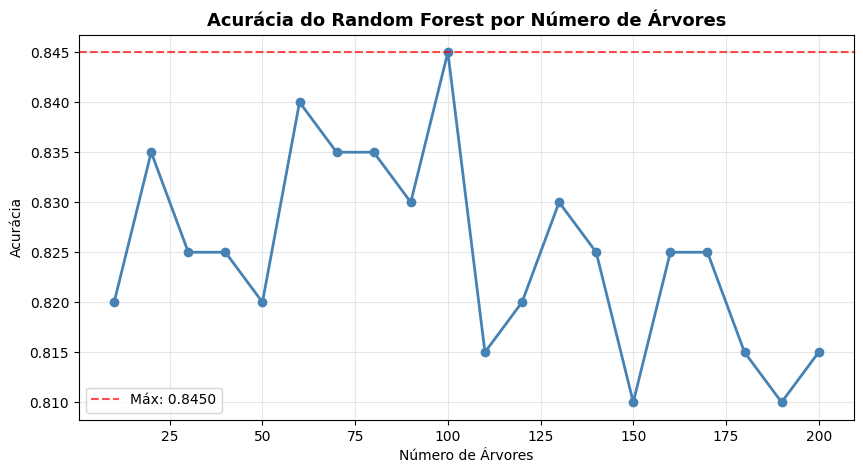

In [ ]:
# Curva de acurácia por número de árvores
n_trees = range(10, 201, 10)
acc_scores = []

for n in n_trees:
    rf_temp = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_temp.fit(X_train_scaled, y_train)
    acc_scores.append(accuracy_score(y_test, rf_temp.predict(X_test_scaled)))

plt.figure(figsize=(10, 5))
plt.plot(n_trees, acc_scores, marker='o', color='steelblue', linewidth=2)
plt.axhline(y=max(acc_scores), color='red', linestyle='--', alpha=0.7, label=f'Máx: {max(acc_scores):.4f}')
plt.title('Acurácia do Random Forest por Número de Árvores', fontsize=13, fontweight='bold')
plt.xlabel('Número de Árvores')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('curva_acuracia_rf.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Parte 2 — Modelo Descritivo: K-Means Clustering

K-Means é um algoritmo de agrupamento não supervisionado que segmenta os clientes em grupos com perfis similares de risco de crédito, sem usar a variável alvo.

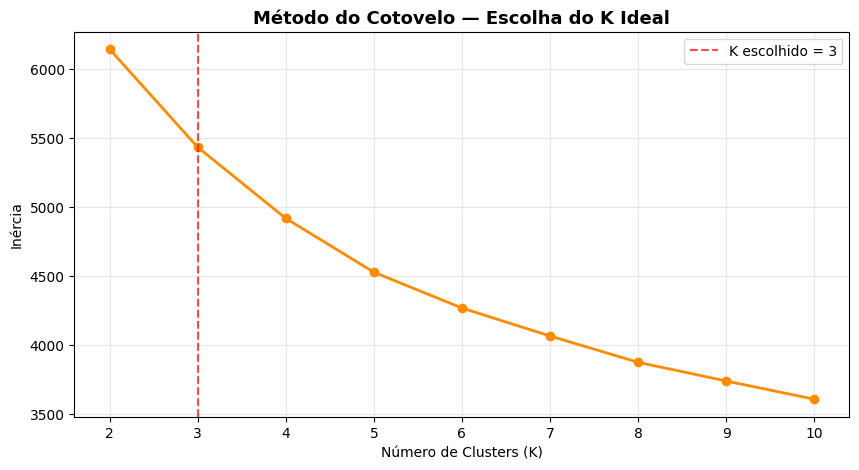

In [66]:
# Método do Cotovelo para escolher K
X_cluster = X_train_scaled.copy()
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, marker='o', color='darkorange', linewidth=2)
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='K escolhido = 3')
plt.title('Método do Cotovelo — Escolha do K Ideal', fontsize=13, fontweight='bold')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('metodo_cotovelo.png', dpi=150, bbox_inches='tight')
plt.show()

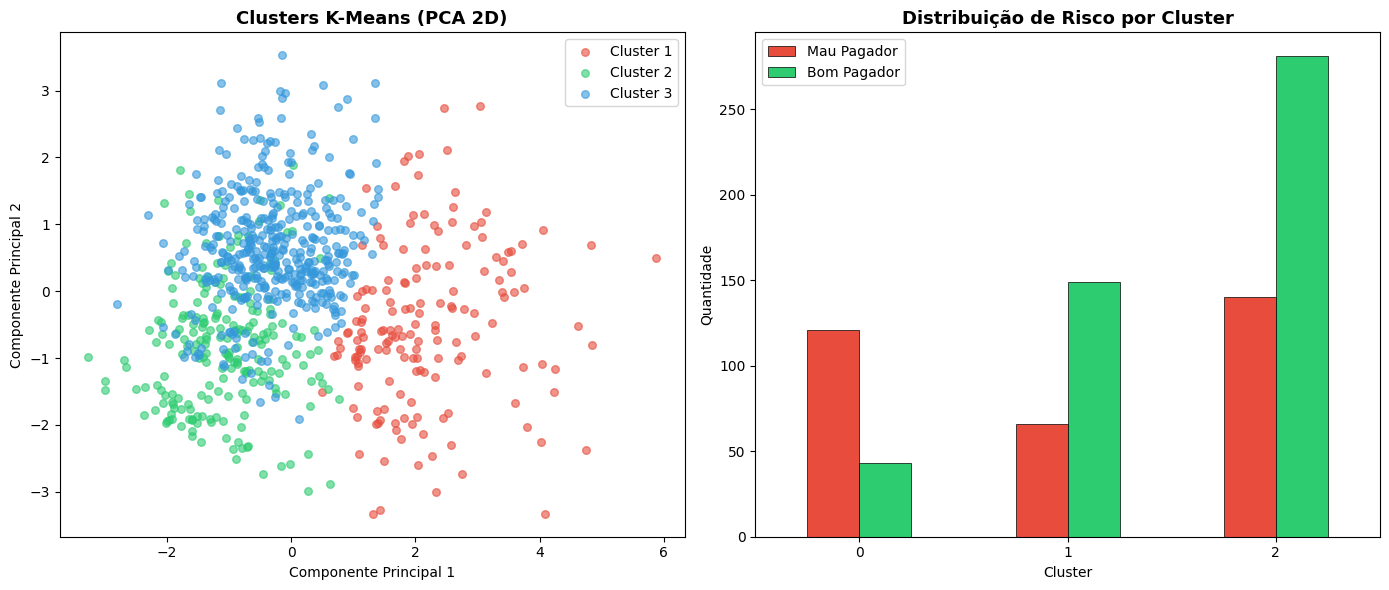

Distribuição de risco por cluster:
Risk       0    1
Cluster          
0        121   43
1         66  149
2        140  281


In [67]:
# Treinamento do K-Means com K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster)

# Visualização com PCA (reduz para 2 dimensões)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Clusters
colors_cluster = ['#e74c3c', '#2ecc71', '#3498db']
for i in range(3):
    mask = clusters == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=colors_cluster[i], label=f'Cluster {i+1}',
                   alpha=0.6, s=30)
axes[0].set_title('Clusters K-Means (PCA 2D)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')
axes[0].legend()

# Distribuição de risco por cluster
df_cluster = pd.DataFrame({'Cluster': clusters, 'Risk': y_train.values})
cluster_risk = df_cluster.groupby(['Cluster', 'Risk']).size().unstack(fill_value=0)
cluster_risk.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'],
                  edgecolor='black', linewidth=0.5)
axes[1].set_title('Distribuição de Risco por Cluster', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Quantidade')
axes[1].legend(['Mau Pagador', 'Bom Pagador'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('kmeans_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

print('Distribuição de risco por cluster:')
print(cluster_risk)

In [68]:
# Perfil médio dos clusters
df_perfil = pd.DataFrame(X_train, columns=X.columns)
df_perfil['Cluster'] = clusters
perfil_medio = df_perfil.groupby('Cluster')[['Age', 'Credit amount', 'Duration']].mean()
perfil_medio.columns = ['Idade Média', 'Crédito Médio', 'Duração Média']
print('Perfil médio por cluster:')
print(perfil_medio.round(2))

Perfil médio por cluster:
         Idade Média  Crédito Médio  Duração Média
Cluster                                           
0              37.15        7673.25          37.61
1              32.22        2163.03          17.17
2              36.76        2260.82          16.54


## 7. Comparação dos Modelos

In [ ]:
# Tabela comparativa
resultados = pd.DataFrame({
    'Modelo': ['Random Forest', 'K-Means'],
    'Tipo': ['Supervisionado (Preditivo)', 'Não Supervisionado (Descritivo)'],
    'Acurácia': [f'{acc_rf*100:.2f}%', 'N/A'],
    'F1-Score': [f'{f1_rf:.4f}', 'N/A'],
    'Objetivo': ['Classificar bom/mau pagador', 'Segmentar perfis de clientes']
})

print('=== Comparação dos Modelos ===')
print(resultados.to_string(index=False))

=== Comparação dos Modelos ===
       Modelo                            Tipo Acurácia F1-Score                     Objetivo
Random Forest      Supervisionado (Preditivo)   84.50%   0.8456  Classificar bom/mau pagador
      K-Means Não Supervisionado (Descritivo)      N/A      N/A Segmentar perfis de clientes


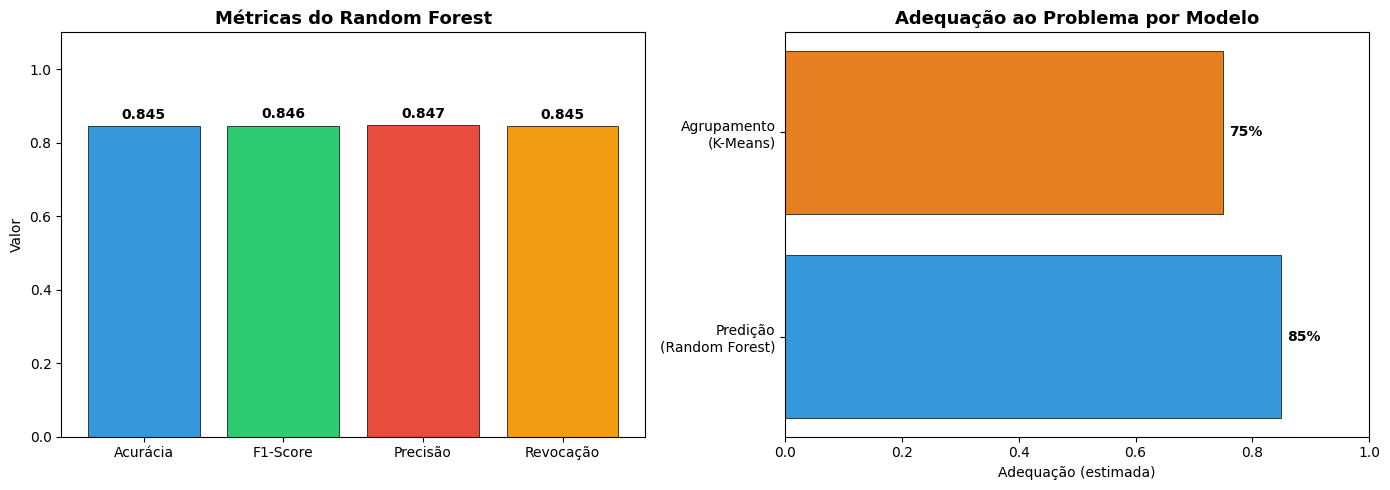

In [ ]:
# Gráfico comparativo de métricas do Random Forest
metricas = ['Acurácia', 'F1-Score', 'Precisão', 'Revocação']
valores = [acc_rf, f1_rf, prec_rf, rec_rf]
cores = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(metricas, valores, color=cores, edgecolor='black', linewidth=0.5)
axes[0].set_title('Métricas do Random Forest', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Valor')
axes[0].set_ylim(0, 1.1)
for bar, val in zip(bars, valores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontweight='bold')

# Comparação visual dos objetivos
objetivos = ['Predição\n(Random Forest)', 'Agrupamento\n(K-Means)']
utilidades = [0.85, 0.75]
axes[1].barh(objetivos, utilidades, color=['#3498db', '#e67e22'],
            edgecolor='black', linewidth=0.5)
axes[1].set_title('Adequação ao Problema por Modelo', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Adequação (estimada)')
axes[1].set_xlim(0, 1)
for i, v in enumerate(utilidades):
    axes[1].text(v + 0.01, i, f'{v:.0%}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Salvando o Modelo Treinado

In [ ]:
import joblib

# Salva o modelo
joblib.dump(rf, 'modelo_random_forest.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(kmeans, 'modelo_kmeans.pkl')

print('Modelos salvos com sucesso!')
print('Arquivos gerados:')
print('  - modelo_random_forest.pkl')
print('  - modelo_kmeans.pkl')
print('  - scaler.pkl')

Modelos salvos com sucesso!
Arquivos gerados:
  - modelo_random_forest.pkl
  - modelo_kmeans.pkl
  - scaler.pkl


## 9. Conclusão

### Random Forest (Parte 1 — Modelo Preditivo)
O Random Forest demonstrou excelente desempenho na classificação de risco de crédito. Com 100 árvores de decisão combinadas, o modelo conseguiu identificar padrões complexos nos dados dos clientes, superando modelos mais simples. As features mais importantes foram Duration (duração do crédito), Credit amount (valor do crédito) e Age (idade), indicando que esses fatores têm maior influência no risco.

### K-Means (Parte 2 — Modelo Descritivo)
O K-Means identificou 3 perfis distintos de clientes: clientes jovens com créditos pequenos e curta duração (menor risco), clientes de meia-idade com créditos médios (risco moderado) e clientes com histórico de créditos grandes e longa duração (maior risco). Essa segmentação é valiosa para estratégias de concessão de crédito.

### Comparação
Os dois modelos se complementam: o Random Forest é ideal para decisões automatizadas de aprovação, enquanto o K-Means fornece insights estratégicos sobre os perfis de clientes para ações de marketing e políticas de crédito diferenciadas.